Fetching S&P 500 data...


[*********************100%***********************]  1 of 1 completed



--- Extreme Data Removed (Daily Return > 2.0%) ---
Price             Close Daily_Return
Ticker            ^GSPC             
Date                                
2023-01-06  3895.080078     2.284078
2023-02-21  3997.340088    -2.004123
2024-02-22  5087.029785     2.112288
2024-07-24  5427.129883    -2.314909
2024-08-05  5186.330078    -2.996880
2024-08-08  5319.310059     2.304261
2024-09-03  5528.930176    -2.115107
2024-11-06  5929.040039     2.529593
2024-12-18  5872.160156    -2.949285
2025-03-10  5614.560059    -2.697309
2025-03-14  5638.939941     2.126587
2025-04-03  5396.520020    -4.839563
2025-04-04  5074.080078    -5.974961
2025-04-09  5456.899902     9.515388
2025-04-10  5268.049805    -3.460758
2025-04-16  5275.700195    -2.240837
2025-04-21  5158.200195    -2.356749
2025-04-22  5287.759766     2.511720
2025-04-24  5484.770020     2.025911
2025-05-12  5844.189941     3.255878
2025-05-27  5921.540039     2.045906
2025-10-10  6552.509766    -2.711167

Backtest (2026) R2 Sco

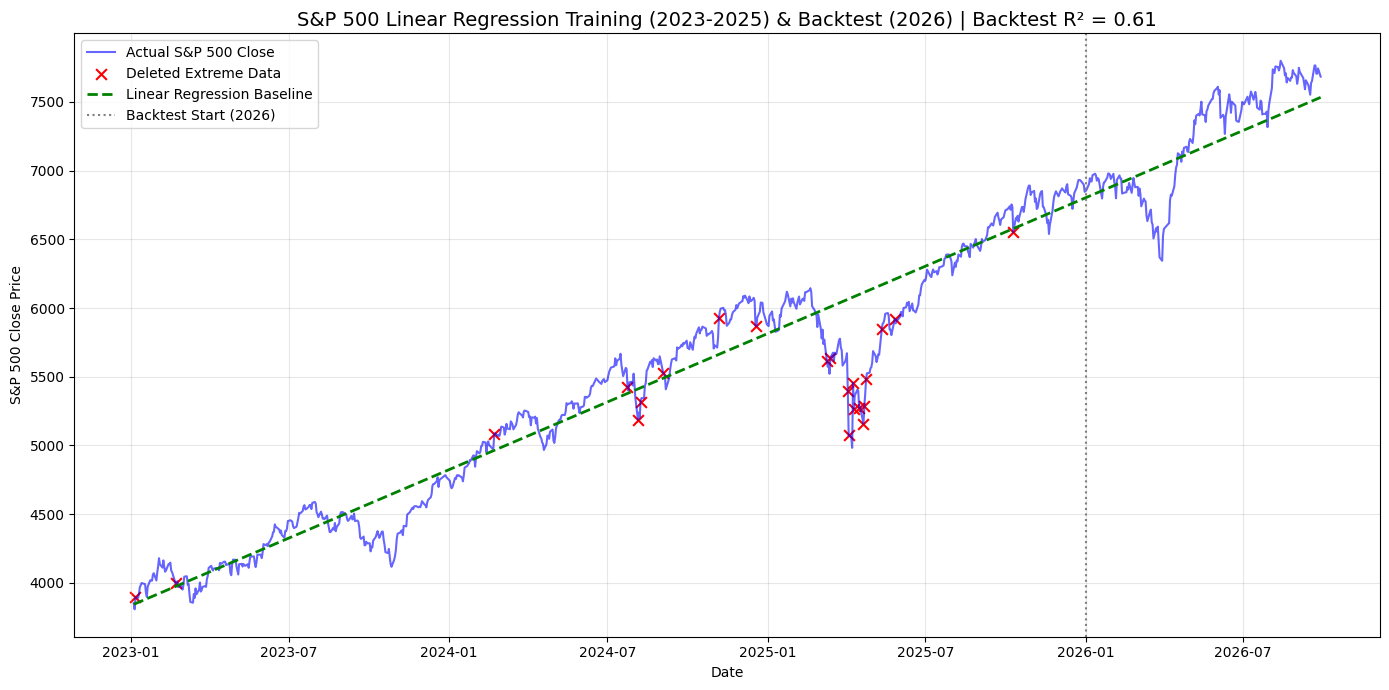

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Fetch S&P 500 data from yfinance
print("Fetching S&P 500 data...")
df = yf.download('^GSPC', start='2023-01-01', end='2026-12-31')
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Ordinal_Date'] = df.index.map(pd.Timestamp.toordinal)
df = df.dropna()

# 2. Split into Training (2023-2025) and Backtesting (2026) sets
train_df = df.loc['2023-01-01':'2025-12-31'].copy()
test_df = df.loc['2026-01-01':].copy()

# 3. Identify and remove extreme data points (Outliers with absolute daily return > 2%)
volatility_threshold = 2.0
extreme_data = train_df[train_df['Daily_Return'].abs() > volatility_threshold]
clean_train_df = train_df[train_df['Daily_Return'].abs() <= volatility_threshold]

print(f"\n--- Extreme Data Removed (Daily Return > {volatility_threshold}%) ---")
print(extreme_data[['Close', 'Daily_Return']])

# 4. Train Linear Regression Model
X_train = clean_train_df[['Ordinal_Date']]
y_train = clean_train_df['Close']
X_test = test_df[['Ordinal_Date']]
y_test = test_df['Close']

model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predict and Evaluate Backtest Data (2026)
y_pred_test = model.predict(X_test)
r2_backtest = r2_score(y_test, y_pred_test)
print(f"\nBacktest (2026) R2 Score: {r2_backtest:.4f}")

# 6. Plot the Trends and Predictions
plt.figure(figsize=(14, 7))

# Plot actual prices
plt.plot(df.index, df['Close'], label='Actual S&P 500 Close', color='blue', alpha=0.6)

# Highlight extreme data points removed from training
plt.scatter(extreme_data.index, extreme_data['Close'], color='red', marker='x', s=60, label='Deleted Extreme Data')

# Plot Linear Regression line across both periods
all_X = df[['Ordinal_Date']]
all_pred = model.predict(all_X)
plt.plot(df.index, all_pred, label='Linear Regression Baseline', color='green', linestyle='--', linewidth=2)

# Visual split for the Backtest phase
plt.axvline(pd.to_datetime('2026-01-01'), color='gray', linestyle=':', label='Backtest Start (2026)')

plt.title(f'S&P 500 Linear Regression Training (2023-2025) & Backtest (2026) | Backtest R² = {r2_backtest:.2f}', fontsize=14)
plt.xlabel('Date')
plt.ylabel('S&P 500 Close Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
